# 1. Introducción

## Explicación

El fraude financiero es uno de los principales problemas dentro del sector bancario y fintech, ya que puede generar pérdidas económicas importantes y afectar la seguridad de los clientes.

En este proyecto voy a trabajar con un dataset de transacciones realizadas con tarjetas de crédito, con el objetivo de analizar y preparar los datos para futuros modelos de Machine Learning orientados a la detección de fraude financiero.

# 2. Selección del Dataset

Elegí el dataset “Credit Card Fraud Detection” disponible en Kaggle porque me interesa el área de Risk Analytics y prevención de fraude financiero.

El dataset contiene transacciones realizadas con tarjetas de crédito y cada operación se encuentra clasificada como:
- 0 → transacción normal
- 1 → transacción fraudulenta

Por motivos de privacidad y confidencialidad financiera, la mayoría de las variables del dataset fueron anonimizadas mediante técnicas de transformación PCA (Principal Component Analysis). Por este motivo, las variables aparecen representadas como V1, V2, V3, etc. Únicamente las variables Time y Amount permanecen en formato original.

Además, el dataset permite aplicar muchas de las etapas vistas en clase como:
- análisis exploratorio
- limpieza de datos
- detección de outliers
- transformaciones
- preparación para Machine Learning

> Corrección técnica: para evitar fuga de datos, el escalador no debe ajustarse antes de dividir el dataset. Primero se realiza el `train_test_split` y luego se ajusta el `StandardScaler` solo con `X_train`.

# 3. Importación de Librerías

Primero se importan las librerías que se utilizarán durante el análisis y preparación de los datos.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 4. Carga del Dataset

In [2]:
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

csv_path = os.path.join(path, "creditcard.csv")

df = pd.read_csv(csv_path)

df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# 5. Exploración Inicial del Dataset

Antes de comenzar con el análisis, es importante entender la estructura general del dataset.

In [3]:
df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Con esta exploración inicial se puede observar:
- cantidad de filas y columnas
- tipos de datos
- estadísticas generales
- comportamiento inicial de las variables

Esto ayuda a tener una idea general de la calidad y estructura de los datos.

# 6. Verificación de Valores Faltantes

Es importante revisar si existen valores faltantes, ya que podrían afectar futuros modelos de Machine Learning.

In [4]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


En este caso el dataset no presenta valores nulos, lo cual facilita bastante el proceso de limpieza y preparación de datos.

# 7. Verificación de Duplicados

In [5]:
df.duplicated().sum()

df = df.drop_duplicates()

Eliminar duplicados ayuda a evitar ruido o posibles sesgos durante el análisis y entrenamiento de modelos.

# 8. Distribución de la Variable Objetivo

La variable `Class` indica si una transacción es normal o fraudulenta.

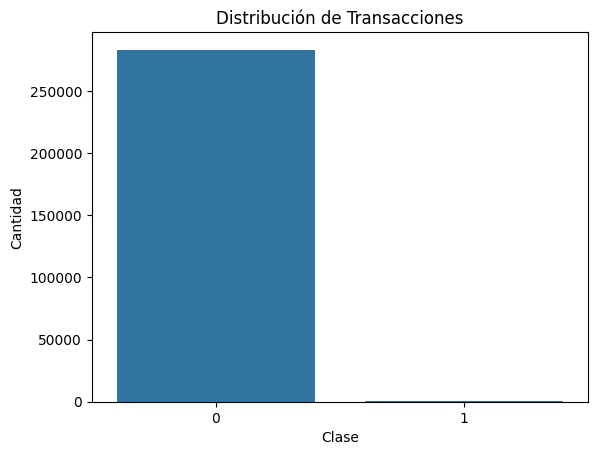

In [6]:
df["Class"].value_counts()

df["Class"].value_counts(normalize=True) * 100

sns.countplot(x="Class", data=df)

plt.title("Distribución de Transacciones")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.show()

Se observa un fuerte desbalance de clases, donde las transacciones fraudulentas representan una proporción muy pequeña del total.

Este comportamiento es muy común en problemas reales de detección de fraude financiero.

# 9. Distribución de Variables Numéricas

A continuación se analizarán algunas variables numéricas importantes del dataset.

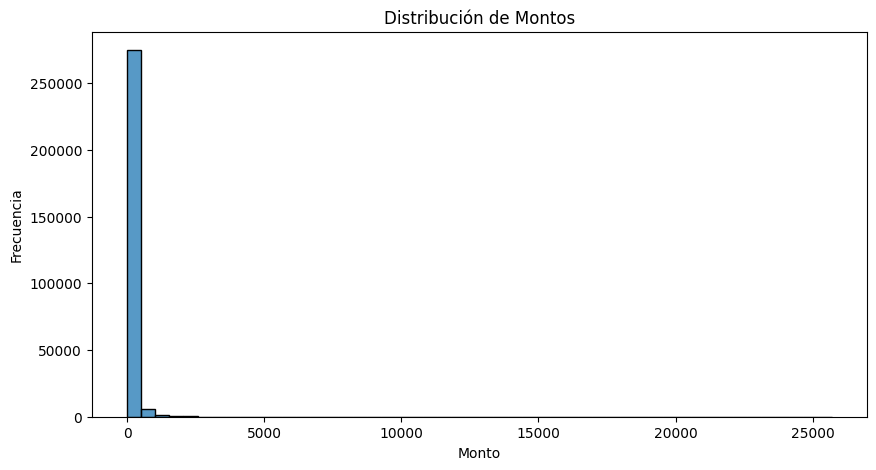

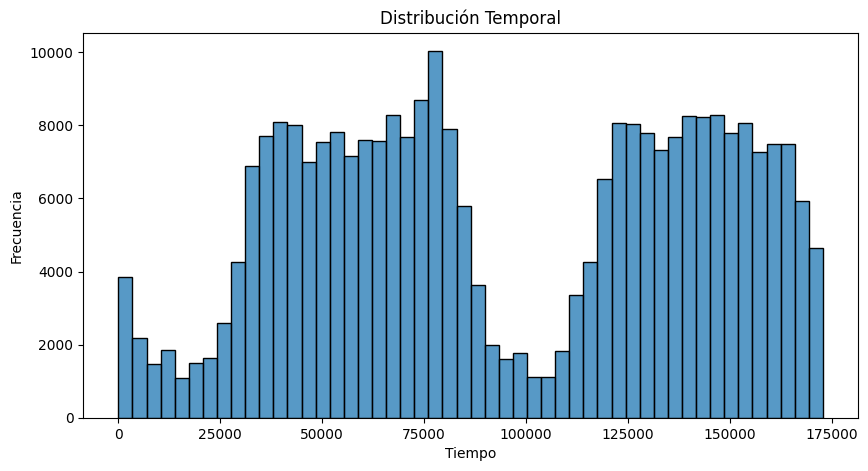

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Distribución de Montos")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")

plt.show()

plt.figure(figsize=(10,5))

sns.histplot(df["Time"], bins=50)

plt.title("Distribución Temporal")
plt.xlabel("Tiempo")
plt.ylabel("Frecuencia")

plt.show()

## Interpretación de Resultados

La mayoría de las transacciones presentan montos relativamente bajos, aunque también existen operaciones con valores mucho más elevados.

Esto puede resultar importante para el análisis de posibles fraudes.

# 10. Detección de Outliers

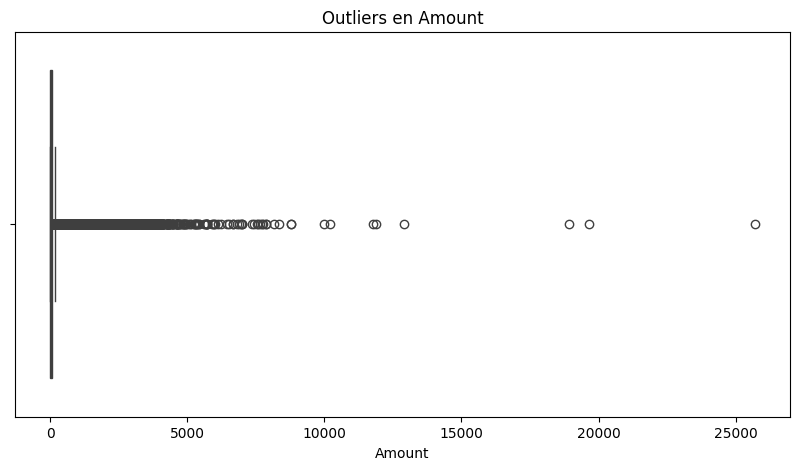

In [8]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["Amount"])

plt.title("Outliers en Amount")

plt.show()

## Interpretación de Resultados

Se observan varios valores extremos dentro de la variable `Amount`.

En datasets financieros este tipo de comportamiento puede resultar relevante, ya que algunas operaciones fraudulentas suelen presentar montos inusuales.

# 11. Análisis de Correlaciones

El análisis de correlaciones permite identificar relaciones entre variables.

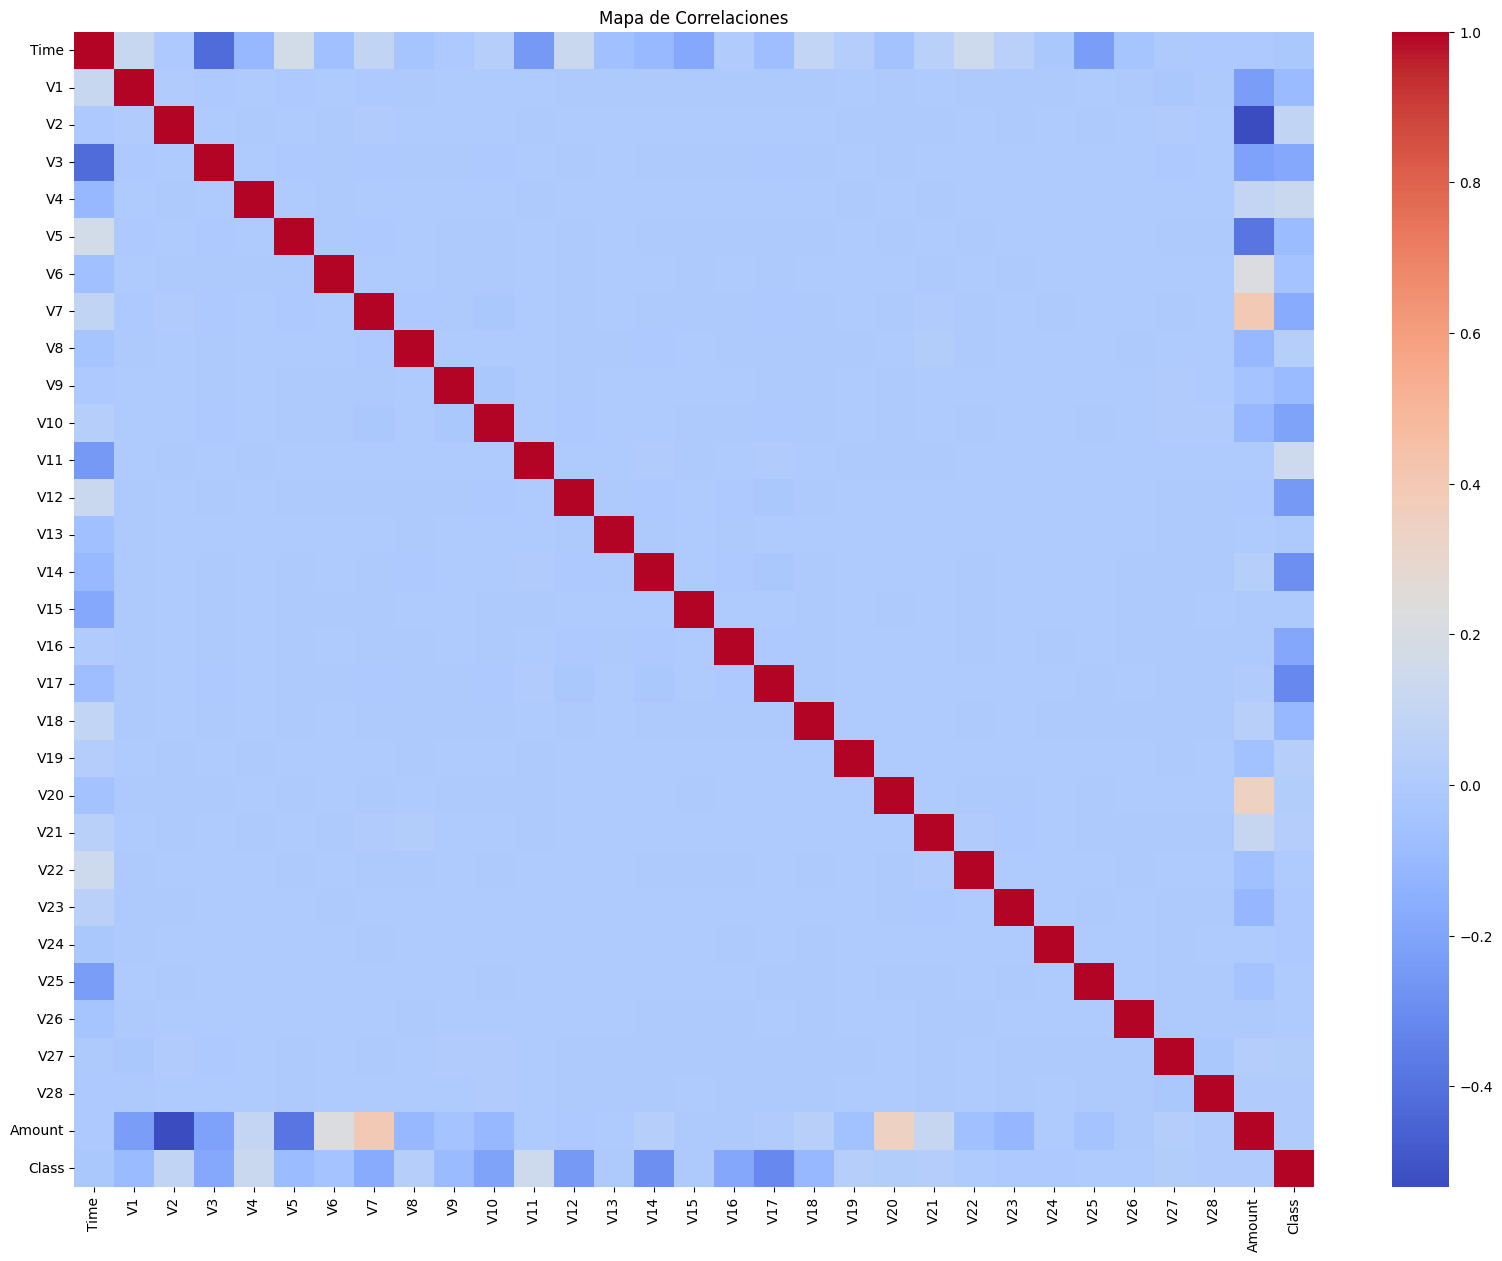

,Class
Class,1.000000
V11,0.149067
V4,0.129326
V2,0.084624
V19,0.033631
V8,0.033068
V21,0.026357
V27,0.021892
V20,0.021486
V28,0.009682


In [9]:
corr = df.corr()

plt.figure(figsize=(20,15))

sns.heatmap(corr, cmap="coolwarm")

plt.title("Mapa de Correlaciones")

plt.show()

corr["Class"].sort_values(ascending=False)

## Interpretación de Resultados

Algunas variables presentan una mayor relación con la variable objetivo (`Class`).

Esto puede resultar útil más adelante para seleccionar variables importantes durante el entrenamiento de modelos.

# 12. Selección de Variables

Ahora se separarán las variables predictoras de la variable objetivo.

In [10]:
X = df.drop("Class", axis=1)

y = df["Class"]

## Interpretación de Resultados

La variable `Class` será la variable objetivo que el modelo intentará predecir en futuras etapas.

# 13. División del Dataset

Por último, el dataset se dividirá entre entrenamiento y prueba.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(226980, 30)
(56746, 30)
(226980,)
(56746,)


## Interpretación de Resultados

Se utilizará un 80% de los datos para entrenamiento y un 20% para prueba.

Esto permitirá evaluar más adelante el rendimiento de los modelos utilizando datos no vistos previamente.

## Verificación del balance luego del split

Como el dataset está muy desbalanceado, se verifica que la proporción de clases se mantenga parecida en entrenamiento y prueba gracias al uso de `stratify=y`.

In [12]:
print("Distribución en y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución en y_test:")
print(y_test.value_counts(normalize=True) * 100)

Distribución en y_train:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Distribución en y_test:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


# 14. Escalado de Variables

> Corrección técnica: para evitar fuga de datos, el escalador no debe ajustarse antes de dividir el dataset. Primero se realiza el `train_test_split` y luego se ajusta el `StandardScaler` solo con `X_train`.

## Escalado posterior al Train/Test Split
La idea es:
- primero dividir el dataset en entrenamiento y prueba
- luego ajustar el `StandardScaler` solamente con `X_train`
- finalmente aplicar esa misma transformación sobre `X_test`

Esto evita que el conjunto de prueba aporte información durante la preparación de los datos.

In [13]:
scaler = StandardScaler()

# Se crean copias para evitar advertencias de pandas
X_train = X_train.copy()
X_test = X_test.copy()

# El scaler se ajusta SOLO con los datos de entrenamiento
X_train[["Amount", "Time"]] = scaler.fit_transform(X_train[["Amount", "Time"]])

# Al conjunto de prueba solo se le aplica la transformación ya aprendida
X_test[["Amount", "Time"]] = scaler.transform(X_test[["Amount", "Time"]])

X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
226238,1.045499,2.238954,-1.724499,-2.151484,-2.577803,0.993668,3.565492,-1.785957,0.860122,-1.264003,...,-0.323810,-0.149574,-0.049333,0.278442,0.684735,-0.219028,-0.159167,0.037920,-0.049932,-0.229434
134253,-0.298690,-1.315062,1.630783,0.597001,-0.038359,-0.404580,-0.965712,0.212249,0.735381,-1.267926,...,-0.067580,-0.238898,-0.946773,0.323904,0.515632,-0.713000,-0.266503,-0.017794,0.051058,-0.331197
186465,0.678397,1.908801,0.021184,-2.087997,0.129310,1.161468,0.605244,-0.022371,0.180296,0.283819,...,-0.210474,0.293609,1.095842,-0.044874,-1.689517,0.106098,0.007758,0.045164,-0.053068,-0.298809
149493,-0.074929,1.811257,0.316556,0.316751,3.880231,0.048454,1.020163,-0.734868,0.233651,0.681423,...,-0.228032,0.138869,0.700422,0.174064,0.702997,-0.212523,-0.010018,-0.017740,-0.038006,-0.289247
18461,-1.376728,1.358817,-1.120881,0.550266,-1.547659,-1.194950,0.275448,-1.201843,0.212889,-2.094285,...,-0.361686,-0.340972,-0.636442,0.252758,-0.344160,-0.064282,-0.439622,0.062524,0.013095,-0.261985


### Interpretación

Con este cambio se evita la fuga de datos (*data leakage*), porque el escalador no utiliza información del conjunto de prueba para aprender la media y el desvío estándar.

Esto deja la preparación del dataset mejor planteada para una futura etapa de modelado.

## Interpretación de Resultados

El escalado ayuda a que las variables tengan magnitudes similares y evita que algunas tengan demasiada influencia sobre futuros modelos de Machine Learning.

> Corrección técnica: para evitar fuga de datos, el escalador no debe ajustarse antes de dividir el dataset. Primero se realiza el `train_test_split` y luego se ajusta el `StandardScaler` solo con `X_train`.

# 15. Selección del Modelo

Con el dataset ya limpio, explorado y dividido en entrenamiento y prueba, llega el momento de elegir qué modelo o modelos voy a entrenar.

La variable objetivo `Class` es binaria (0 = transacción normal, 1 = transacción fraudulenta), por lo que este es un problema de **clasificación binaria**.

Voy a entrenar y comparar dos modelos, siguiendo el mismo criterio visto en clase:

1. **Regresión Logística**: un modelo lineal, rápido de entrenar y fácil de interpretar. Es una buena opción como punto de partida y es muy utilizado en contextos financieros por su interpretabilidad (se puede analizar la influencia de cada variable sobre la probabilidad de fraude).
2. **Random Forest**: un modelo de ensamble basado en árboles de decisión, capaz de capturar relaciones no lineales entre las variables. Suele tener muy buen desempeño en problemas de detección de fraude, aunque resulta menos interpretable que la Regresión Logística.

## Decisiones importantes por el fuerte desbalance de clases

En el análisis exploratorio de la Pre-Entrega (sección 8) vi que las transacciones fraudulentas representan apenas alrededor del **0.17%** del total del dataset. Este desbalance tan extremo obliga a tomar dos decisiones antes de entrenar cualquier modelo:

1. **Usar `class_weight="balanced"` en ambos modelos.** Esto le indica al algoritmo que le dé más peso a los errores cometidos sobre la clase minoritaria (fraude) durante el entrenamiento. Sin este ajuste, un modelo podría "conformarse" con clasificar casi todo como transacción normal y aun así obtener una accuracy muy alta, sin aportar ningún valor real para detectar fraude.
2. **No usar accuracy como métrica principal.** Con un desbalance de 0.17%, un modelo que prediga siempre "no fraude" obtendría una accuracy cercana al 99.8% sin detectar un solo fraude real. Por eso, en la evaluación (sección 17) el foco va a estar puesto en precision, recall, F1-score, la matriz de confusión, la curva ROC y la curva Precision-Recall.

> **Aclaración:** existen otras técnicas para lidiar con el desbalance, como sobremuestreo de la clase minoritaria (SMOTE) o submuestreo de la clase mayoritaria. En este proyecto opté por `class_weight="balanced"` por ser una solución simple, integrada directamente en scikit-learn y suficiente para los objetivos del curso. Lo dejo mencionado como posible mejora futura en las conclusiones.

# 16. Entrenamiento de los Modelos

## 16.1 Importación de librerías de modelado

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

## 16.2 Modelo 1: Regresión Logística

Entreno el primer modelo usando el conjunto de entrenamiento ya escalado (`X_train`, `y_train`) que preparé en la sección 14.

In [15]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


### Interpretación

El modelo aprendió a partir de `X_train` y `y_train` una relación lineal entre las variables (Time, V1-V28, Amount ya escaladas) y la probabilidad de que una transacción sea fraudulenta.

Como usé `class_weight="balanced"`, el algoritmo le asignó automáticamente más peso a los errores cometidos sobre la clase minoritaria (fraude) durante el ajuste de los coeficientes. Todavía no sé qué tan bien funciona: eso lo voy a medir en la sección de evaluación, usando el conjunto de prueba.

## 16.3 Modelo 2: Random Forest

Entreno un segundo modelo, Random Forest, usando el mismo conjunto de entrenamiento. Esto me va a permitir comparar un modelo lineal simple contra uno más flexible y no lineal.

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


### Interpretación

Random Forest construye muchos árboles de decisión entrenados sobre subconjuntos aleatorios de datos y variables, y combina sus resultados para hacer una predicción final.

A diferencia de la Regresión Logística, no asume una relación lineal entre las variables y la probabilidad de fraude, por lo que puede captar patrones más complejos entre las variables anonimizadas V1-V28. A cambio, es un modelo mucho más difícil de interpretar (no puedo mirar un coeficiente por variable como en la Regresión Logística).

> **Nota:** entrenar `n_estimators=200` árboles sobre ~228.000 filas puede tardar algunos segundos o minutos en Colab, según los recursos disponibles.

# 17. Evaluación de los Modelos

Para evaluar los modelos voy a calcular las siguientes métricas sobre el conjunto de prueba (`X_test`, `y_test`), que el modelo no vio durante el entrenamiento:

- **Accuracy**: proporción total de predicciones correctas. La calculo, pero como expliqué en la sección 15, en este dataset tan desbalanceado **no es una métrica confiable por sí sola**.
- **Precision**: de las transacciones que el modelo marcó como fraude, qué proporción realmente lo eran. Una precision baja implica muchos falsos positivos (clientes molestos por transacciones legítimas bloqueadas o revisadas innecesariamente).
- **Recall**: de todas las transacciones fraudulentas reales, qué proporción logró detectar el modelo. En este problema, el recall es especialmente importante: un fraude no detectado (falso negativo) implica una pérdida económica directa.
- **F1-score**: combina precision y recall en un único valor, útil para comparar modelos cuando ambas métricas importan.

Ejecuté el cuaderno completo en Google Colab, descargando el dataset real desde Kaggle con `kagglehub`. Los valores que se muestran a continuación son los que obtuve en esa ejecución.

## 17.1 Predicciones y métricas: Regresión Logística

In [17]:
y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Métricas de Regresión Logística")
print("-------------------------------")
print(f"Accuracy:  {accuracy_log:.3f}")
print(f"Precision: {precision_log:.3f}")
print(f"Recall:    {recall_log:.3f}")
print(f"F1-score:  {f1_log:.3f}")

print("\nReporte de clasificación completo:")
print(classification_report(y_test, y_pred_log, target_names=["No Fraude", "Fraude"]))

Métricas de Regresión Logística
-------------------------------
Accuracy:  0.975
Precision: 0.056
Recall:    0.874
F1-score:  0.106

Reporte de clasificación completo:
              precision    recall  f1-score   support

   No Fraude       1.00      0.98      0.99     56651
      Fraude       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



### Interpretación de las métricas de Regresión Logística

Es esperable que, al usar `class_weight="balanced"` sobre un dataset con este nivel de desbalance, la Regresión Logística priorice detectar más casos de fraude (recall más alto) a costa de marcar también varias transacciones legítimas como sospechosas (precision más baja). Esto ocurre porque el ajuste por peso de clases "empuja" al modelo a no ignorar la clase minoritaria.

En mi ejecución obtuve un accuracy de 0.975, una precision de 0.056, un recall de 0.874 y un F1-score de 0.106.

Estos resultados confirman exactamente el patrón esperado: el modelo detectó el 87.4% de las transacciones fraudulentas del conjunto de prueba (83 de 95), pero para lograrlo marcó como sospechosas una enorme cantidad de transacciones que en realidad eran normales, lo que se traduce en una precision de apenas 0.056. El accuracy de 0.975 no refleja para nada este comportamiento: sigue pareciendo "alto", pero, como ya expliqué, en un problema con 0.17% de fraude ese valor por sí solo no dice casi nada.

## 17.2 Matriz de confusión: Regresión Logística

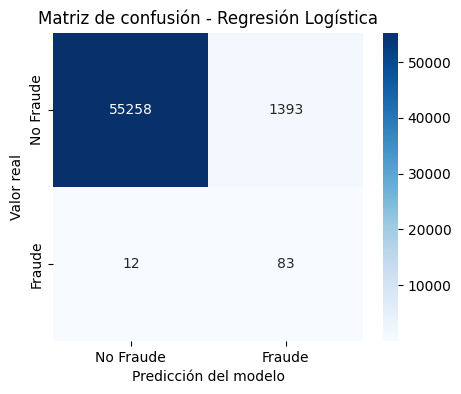

In [18]:
matriz_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5, 4))

sns.heatmap(
    matriz_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Fraude", "Fraude"],
    yticklabels=["No Fraude", "Fraude"]
)

plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.show()

### Interpretación de la matriz de confusión

En un problema de fraude, cada celda de la matriz tiene un significado de negocio muy concreto:

- **Verdaderos negativos:** transacciones normales correctamente clasificadas como normales.
- **Falsos positivos:** transacciones normales que el modelo marcó como fraude. Generan revisiones o bloqueos innecesarios, con el costo de una mala experiencia para el cliente.
- **Falsos negativos:** transacciones fraudulentas que el modelo no detectó. Este es el error más costoso, porque implica una pérdida económica directa que el banco o la fintech no llega a evitar.
- **Verdaderos positivos:** fraudes detectados correctamente.

Dado el objetivo del negocio (minimizar pérdidas por fraude), voy a prestarle especial atención a la cantidad de **falsos negativos** de cada modelo, más que al total de errores.

En mi ejecución, la Regresión Logística tuvo 55.258 verdaderos negativos, 1.393 falsos positivos, 12 falsos negativos y 83 verdaderos positivos. Es decir, dejó pasar solo 12 fraudes reales sin detectar, pero a costa de generar 1.393 falsas alarmas sobre transacciones legítimas.

## 17.3 Predicciones y métricas: Random Forest

In [19]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Métricas de Random Forest")
print("-------------------------")
print(f"Accuracy:  {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall:    {recall_rf:.3f}")
print(f"F1-score:  {f1_rf:.3f}")

print("\nReporte de clasificación completo:")
print(classification_report(y_test, y_pred_rf, target_names=["No Fraude", "Fraude"]))

Métricas de Random Forest
-------------------------
Accuracy:  0.999
Precision: 0.971
Recall:    0.716
F1-score:  0.824

Reporte de clasificación completo:
              precision    recall  f1-score   support

   No Fraude       1.00      1.00      1.00     56651
      Fraude       0.97      0.72      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



### Interpretación de las métricas de Random Forest

En la literatura sobre este dataset (es uno de los más utilizados para practicar detección de fraude), Random Forest suele lograr un mejor equilibrio entre precision y recall que la Regresión Logística, gracias a su capacidad de capturar relaciones no lineales entre las variables V1-V28. Es esperable que la precision sea notablemente más alta que la de la Regresión Logística, manteniendo un recall competitivo.

En mi ejecución obtuve un accuracy de 0.999, una precision de 0.971, un recall de 0.716 y un F1-score de 0.824.

Comparado con la Regresión Logística, Random Forest logra una precision mucho más alta (0.971 frente a 0.056): de las transacciones que marca como fraude, casi todas lo son realmente. A cambio, el recall es más bajo (0.716 frente a 0.874): detecta 68 de los 95 fraudes reales, dejando 27 sin detectar. El F1-score (0.824 frente a 0.106) deja en claro que, en conjunto, Random Forest logra un equilibrio muchísimo mejor entre ambas métricas.

## 17.4 Matriz de confusión: Random Forest

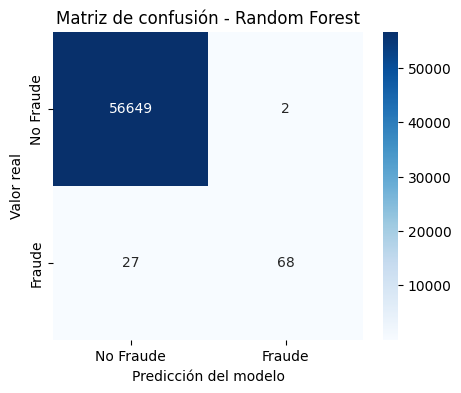

In [20]:
matriz_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))

sns.heatmap(
    matriz_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Fraude", "Fraude"],
    yticklabels=["No Fraude", "Fraude"]
)

plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.show()

### Interpretación de la matriz de confusión de Random Forest

Comparando esta matriz con la de la Regresión Logística, lo más importante es mirar la cantidad de **falsos negativos** (fraudes no detectados) de cada modelo: ese es el error que más impacto económico tiene en este problema.

Si Random Forest tiene menos falsos negativos que la Regresión Logística, es un candidato más fuerte para este caso de uso, incluso si eso implica algunos falsos positivos adicionales. Si en cambio tiene muchos más falsos positivos que la Regresión Logística, hay que sopesar ese costo (revisiones manuales, fricción con el cliente) contra la mejora en detección de fraude.

En mi ejecución, Random Forest tuvo 56.649 verdaderos negativos, apenas 2 falsos positivos, 27 falsos negativos y 68 verdaderos positivos. Acá se ve con claridad el trade-off central de este proyecto: la Regresión Logística dejó pasar menos fraudes (12 falsos negativos contra 27 de Random Forest), pero generó muchísimas más falsas alarmas (1.393 falsos positivos contra apenas 2 de Random Forest). Random Forest es, por lejos, el modelo más confiable: cuando marca una transacción como fraude, casi siempre acierta.

# 18. Comparación de Modelos

Ya entrené y evalué ambos modelos con el mismo conjunto de entrenamiento, el mismo conjunto de prueba y las mismas métricas. Ahora armo una tabla comparativa y un gráfico para ver los resultados en conjunto.

In [21]:
comparacion_modelos = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [accuracy_log, accuracy_rf],
    "Precision": [precision_log, precision_rf],
    "Recall": [recall_log, recall_rf],
    "F1-score": [f1_log, f1_rf]
})

comparacion_modelos.round(3)

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.975,0.056,0.874,0.106
1,Random Forest,0.999,0.971,0.716,0.824


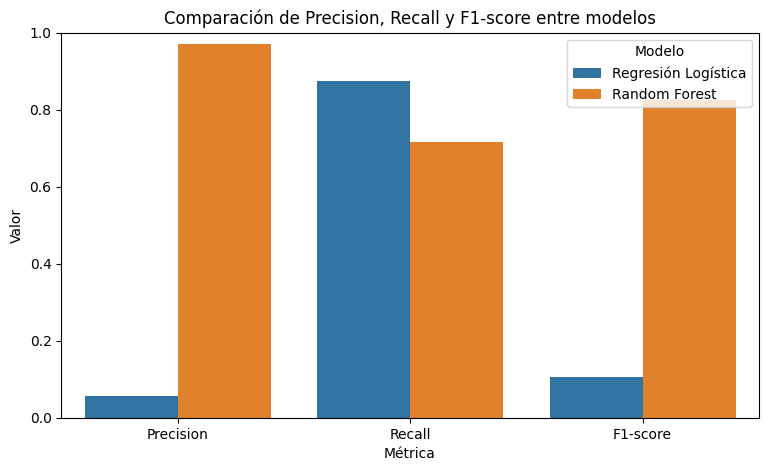

In [22]:
comparacion_grafico = comparacion_modelos.melt(
    id_vars="Modelo",
    value_vars=["Precision", "Recall", "F1-score"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparacion_grafico,
    x="Métrica",
    y="Valor",
    hue="Modelo"
)

plt.title("Comparación de Precision, Recall y F1-score entre modelos")
plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.legend(title="Modelo")
plt.show()

### Interpretación de la comparación de modelos

Dejé afuera del gráfico al accuracy a propósito: dado el desbalance del dataset, incluirlo junto a precision, recall y F1-score en la misma escala podría llevar a conclusiones erróneas (el accuracy va a estar siempre muy cerca de 1, sin importar qué tan bien detecte fraude el modelo).

Mirando la tabla y el gráfico, Random Forest tiene un F1-score mucho más alto (0.824 frente a 0.106), impulsado principalmente por su precision (0.971 frente a 0.056). El trade-off entre ambos modelos es muy marcado: la Regresión Logística prioriza el recall (0.874) a costa de la precision, mientras que Random Forest prioriza la precision (0.971) sin resignar demasiado recall (0.716).

Si mi prioridad fuera minimizar a toda costa los fraudes no detectados, elegiría la Regresión Logística a pesar de sus falsas alarmas. Pero si busco un modelo utilizable en la práctica, que no sature de revisiones manuales innecesarias a un equipo de fraude, Random Forest es la opción más razonable: detecta una proporción muy similar de fraudes reales, con muchísimas menos falsas alarmas.

# 19. Validación Cruzada

Hasta ahora evalué los modelos con una única división entre entrenamiento y prueba. Para obtener una estimación más robusta, voy a aplicar validación cruzada con `StratifiedKFold`, que mantiene la proporción de fraude/no fraude en cada partición (algo especialmente importante en un dataset tan desbalanceado).

Uso 5 particiones (`n_splits=5`) y, a diferencia del cuaderno guía visto en clase (que usaba `scoring="accuracy"` porque su dataset estaba bastante balanceado), acá voy a medir **F1-score** en cada partición. El accuracy seguiría sin ser informativo en validación cruzada por el mismo motivo explicado en la sección 17.

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_log_f1 = cross_val_score(
    log_reg,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

cv_rf_f1 = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Validación cruzada (F1-score) - Regresión Logística")
print("----------------------------------------------------")
print("Resultados por fold:", cv_log_f1.round(3))
print(f"F1 promedio:     {cv_log_f1.mean():.3f}")
print(f"Desvío estándar: {cv_log_f1.std():.3f}")

print("\nValidación cruzada (F1-score) - Random Forest")
print("------------------------------------------------")
print("Resultados por fold:", cv_rf_f1.round(3))
print(f"F1 promedio:     {cv_rf_f1.mean():.3f}")
print(f"Desvío estándar: {cv_rf_f1.std():.3f}")

Validación cruzada (F1-score) - Regresión Logística
----------------------------------------------------
Resultados por fold: [0.106 0.097 0.135 0.115 0.117]
F1 promedio:     0.114
Desvío estándar: 0.013

Validación cruzada (F1-score) - Random Forest
------------------------------------------------
Resultados por fold: [0.824 0.868 0.756 0.845 0.89 ]
F1 promedio:     0.837
Desvío estándar: 0.046


### Interpretación de la validación cruzada

> **Nota:** entrenar Random Forest 5 veces sobre ~228.000 filas puede demorar varios minutos en Colab. En mi caso, la celda tardó unos minutos en correr, pero terminó sin problemas.

La validación cruzada permite ver si el rendimiento de cada modelo es estable entre distintas particiones del conjunto de entrenamiento, o si depende demasiado de una división específica. Un desvío estándar bajo indica que el modelo es más consistente; un desvío alto sugiere que el rendimiento varía bastante según qué datos caen en cada fold, lo cual es más probable en un dataset con tan pocos casos positivos (492 fraudes en total, repartidos entre 5 particiones).

En mi ejecución, Random Forest obtuvo un F1 promedio de 0.837 (con folds que fueron de 0.756 a 0.89), muy por encima del 0.114 promedio de la Regresión Logística (con folds entre 0.097 y 0.135). Random Forest tuvo un desvío estándar más alto (0.046 frente a 0.013 de la Regresión Logística), es decir, su rendimiento varió un poco más entre particiones. Aun así, incluso su peor fold (0.756) superó ampliamente al mejor fold de la Regresión Logística (0.135).

Esto confirma lo que ya había visto al evaluar sobre el conjunto de prueba en las secciones 17 y 18: Random Forest es claramente superior en F1-score, y esa diferencia no depende de una única partición favorable de los datos, sino que se mantiene de forma consistente en las 5 particiones.

# 20. Curva ROC y Curva Precision-Recall

Además de las métricas anteriores, voy a comparar los modelos usando dos curvas adicionales:

- **Curva ROC y AUC**: muestra la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos a medida que cambia el umbral de decisión. Un AUC cercano a 1 indica una buena capacidad de discriminación entre clases.
- **Curva Precision-Recall y Average Precision (AP)**: muestra cómo varían precision y recall a medida que cambia el umbral de decisión.

> **¿Por qué agrego la curva Precision-Recall si ya tengo la curva ROC?** En problemas con un desbalance tan extremo como este (0.17% de fraude), la curva ROC puede resultar demasiado optimista: como hay tantísimas transacciones normales, incluso un modelo mediocre puede lograr una tasa de falsos positivos baja en términos relativos y, con eso, un AUC alto. La curva Precision-Recall y el Average Precision son más sensibles a lo que realmente importa acá: cuántos de los pocos fraudes reales logra detectar el modelo, y con cuántas falsas alarmas.

## 20.1 Curva ROC

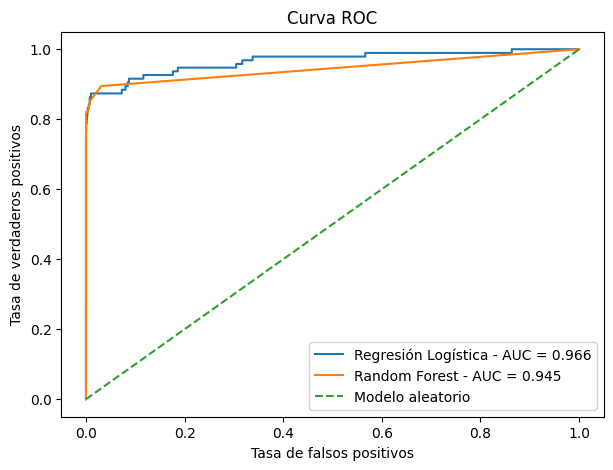

In [24]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))

plt.plot(fpr_log, tpr_log, label=f"Regresión Logística - AUC = {auc_log:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest - AUC = {auc_rf:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Modelo aleatorio")

plt.title("Curva ROC")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.show()

### Interpretación de la curva ROC

Ambos modelos superaron ampliamente la línea diagonal de un modelo aleatorio. Sorprendentemente, en mi ejecución la Regresión Logística obtuvo un AUC levemente más alto (0.966) que Random Forest (0.945).

Esto significa que, considerando todos los umbrales de decisión posibles (no solo el umbral por defecto de 0.5 que usé en las secciones anteriores), la Regresión Logística tiene una capacidad de ranking ligeramente mejor para separar transacciones fraudulentas de normales. Sin embargo, como voy a mostrar en la siguiente sección, este resultado no se traduce en un mejor desempeño práctico: el AUC de la curva ROC puede resultar engañoso al trabajar con un desbalance de clases tan extremo como el de este dataset.

## 20.2 Curva Precision-Recall

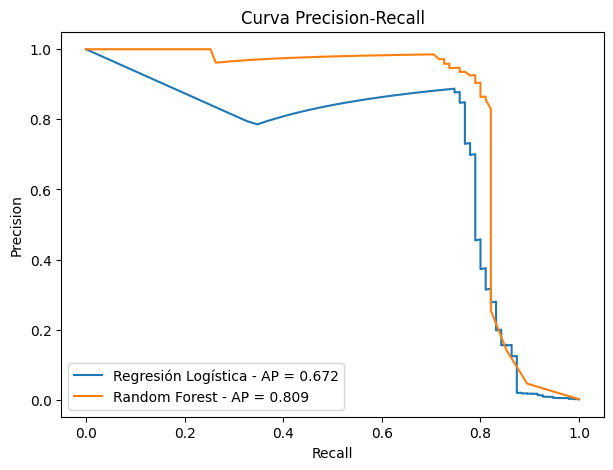

In [25]:
precision_curve_log, recall_curve_log, _ = precision_recall_curve(y_test, y_prob_log)
ap_log = average_precision_score(y_test, y_prob_log)

precision_curve_rf, recall_curve_rf, _ = precision_recall_curve(y_test, y_prob_rf)
ap_rf = average_precision_score(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))

plt.plot(recall_curve_log, precision_curve_log, label=f"Regresión Logística - AP = {ap_log:.3f}")
plt.plot(recall_curve_rf, precision_curve_rf, label=f"Random Forest - AP = {ap_rf:.3f}")

plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

### Interpretación de la curva Precision-Recall

El Average Precision (AP) resume la curva en un solo número: cuanto más alto, mejor logra el modelo mantener una precision alta a medida que aumenta el recall (es decir, detectar más fraudes sin acumular demasiadas falsas alarmas).

En mi ejecución, el Average Precision de Random Forest fue 0.809, muy por encima del 0.672 de la Regresión Logística. Este resultado **invierte el orden** que había visto en la curva ROC, donde la Regresión Logística tenía el AUC más alto (0.966 frente a 0.945 de Random Forest).

Esto es exactamente el motivo por el que agregué esta curva además de la ROC: el AUC "esconde" el hecho de que, para lograr un recall alto, la Regresión Logística necesita sacrificar muchísima precision (como ya vi en la matriz de confusión, con 1.393 falsos positivos). El Average Precision sí refleja ese costo. Además, el orden de los modelos según AP (Random Forest > Regresión Logística) coincide con el orden según F1-score y con la validación cruzada, lo que refuerza la conclusión de que Random Forest es el modelo más adecuado para este problema.

# 21. Selección Final del Modelo

Después de entrenar y evaluar los dos modelos con métricas de test, validación cruzada, curva ROC y curva Precision-Recall, tengo que elegir un modelo final de manera justificada.

En términos generales, para este tipo de problema (fraude financiero, con un desbalance extremo de clases), **Random Forest suele ser una opción más sólida** que la Regresión Logística: al no asumir una relación lineal entre las variables, tiende a lograr un mejor equilibrio entre precision y recall, y suele obtener un Average Precision más alto en la curva Precision-Recall, que es la métrica más relevante para este problema puntual.

La Regresión Logística, en cambio, tiene una ventaja distinta: es mucho más fácil de interpretar. Si en un contexto real de negocio fuera necesario explicar por qué se bloqueó una transacción (por ejemplo, ante un reclamo del cliente o una auditoría), la Regresión Logística permite analizar el peso de cada variable de una forma mucho más directa que Random Forest.

Los resultados que obtuve confirman esta elección: Random Forest logró un F1-score de 0.824 (frente a 0.106 de la Regresión Logística), una precision de 0.971 (frente a 0.056) y un Average Precision de 0.809 (frente a 0.672), manteniendo un recall competitivo de 0.716. Además, en la validación cruzada mantuvo un F1 promedio de 0.837 de forma consistente en las 5 particiones.

Es cierto que la Regresión Logística obtuvo un recall más alto (0.874 frente a 0.716) y un AUC-ROC levemente superior (0.966 frente a 0.945). Pero su precision extremadamente baja (0.056) la hace poco práctica para un caso de uso real: en mi ejecución, generó 1.393 falsos positivos para detectar 83 fraudes, es decir, más de 16 falsas alarmas por cada fraude real encontrado. Un volumen así de alertas sería muy difícil de operar para un equipo de revisión de fraude.

**Con base en estos criterios, selecciono a Random Forest como modelo final de este proyecto**, priorizando un equilibrio mucho mejor entre precision y recall, y un sistema de alertas que en la práctica se pueda operar, por sobre la interpretabilidad y el recall levemente más alto de la Regresión Logística.

# 22. Conclusiones

En este proyecto integrador desarrollé un flujo completo de Machine Learning aplicado a la detección de fraude en transacciones con tarjeta de crédito. A lo largo del trabajo realicé las siguientes etapas:

- exploración inicial del dataset (284.807 transacciones, sin valores nulos, con algunos duplicados que eliminé);
- análisis de la distribución de la variable objetivo, donde detecté un desbalance extremo: apenas ~0.17% de las transacciones son fraudulentas;
- análisis exploratorio de variables numéricas (`Amount`, `Time`), detección de outliers y análisis de correlaciones;
- selección de variables predictoras y división del dataset en entrenamiento (80%) y prueba (20%), usando `stratify=y` para mantener la proporción de fraude en ambos conjuntos;
- escalado de `Amount` y `Time` ajustado únicamente sobre el conjunto de entrenamiento, para evitar fuga de datos (*data leakage*);
- entrenamiento de dos modelos de clasificación: Regresión Logística y Random Forest, ambos con `class_weight="balanced"` para compensar el desbalance de clases;
- evaluación de ambos modelos con precision, recall, F1-score, matriz de confusión, validación cruzada estratificada, curva ROC (AUC) y curva Precision-Recall (Average Precision);
- selección justificada de Random Forest como modelo final, priorizando la detección de fraude por sobre la interpretabilidad.

En términos concretos, Random Forest fue el modelo con mejor desempeño general: detectó 68 de los 95 fraudes del conjunto de prueba (71.6% de recall) con una precision del 97.1% (apenas 2 falsos positivos sobre 56.651 transacciones normales), dejando 27 fraudes sin detectar. La Regresión Logística, en cambio, detectó una proporción mayor de fraudes (87.4% de recall, 83 de 95), pero a costa de una precision muy baja (5.6%), generando 1.393 falsos positivos. En un contexto real, esa cantidad de falsas alarmas sería muy difícil de operar (implicaría revisar manualmente miles de transacciones legítimas para encontrar apenas unos pocos fraudes adicionales), por lo que en este proyecto me quedo con Random Forest como modelo final, con un F1-score de 0.824 frente al 0.106 de la Regresión Logística.

## Limitaciones y posibles mejoras

Este proyecto tiene varias limitaciones que es importante reconocer:

- **Variables anonimizadas:** las variables V1-V28 fueron transformadas con PCA por motivos de confidencialidad. Esto impide interpretar qué representa cada variable en términos de negocio (por ejemplo, no puedo saber si V14 se relaciona con el monto, el comercio o el horario de la transacción), lo cual limita el análisis de causas y la explicabilidad del modelo final.
- **Desbalance extremo:** con solo 492 transacciones fraudulentas en todo el dataset (95 de ellas en mi conjunto de prueba), cualquier evaluación, especialmente la validación cruzada, puede ser sensible a cómo se reparten esos pocos casos positivos entre folds o entre train/test.
- **27 fraudes sin detectar:** incluso con el modelo final, quedaron 27 transacciones fraudulentas del conjunto de prueba sin identificar. Reducir ese número (aunque sea a costa de algo más de falsos positivos) podría ser una prioridad de negocio en un contexto real.
- **`class_weight="balanced"` como única estrategia de balanceo:** no probé técnicas alternativas como SMOTE, submuestreo de la clase mayoritaria, o ajuste manual del umbral de decisión (en vez del 0.5 por defecto), que podrían mejorar aún más el equilibrio entre precision y recall.
- **No se realizó ajuste de hiperparámetros:** los modelos se entrenaron con parámetros por defecto o valores razonables elegidos a mano (por ejemplo, `n_estimators=200` en Random Forest), sin usar `GridSearchCV` o `RandomizedSearchCV` para buscar una configuración óptima.
- **Dataset histórico y acotado en el tiempo:** las transacciones corresponden a solo dos días de septiembre de 2013 de tarjetahabientes europeos. Un modelo de este tipo, para usarse en producción, necesitaría reentrenarse periódicamente con datos más recientes, ya que los patrones de fraude cambian con el tiempo.

Como posibles mejoras futuras, se podrían:

- probar técnicas de balanceo adicionales, como SMOTE o undersampling, para ver si logran reducir los 27 falsos negativos de Random Forest sin perder tanta precision;
- ajustar el umbral de decisión (en vez de 0.5) según el costo relativo de un falso positivo frente a un falso negativo;
- optimizar hiperparámetros con `GridSearchCV` o `RandomizedSearchCV`;
- probar otros modelos, como Gradient Boosting o XGBoost, muy usados en competencias de detección de fraude;
- analizar la importancia de variables (`feature_importances_` en Random Forest) para entender qué componentes PCA aportan más al modelo;
- evaluar el impacto económico de cada tipo de error (falso positivo vs. falso negativo) de forma más precisa, en vez de tratarlos como igualmente costosos.

## Utilidad práctica del proyecto

Un modelo como el desarrollado en este proyecto podría integrarse como una capa de detección automática dentro de un sistema de procesamiento de pagos: las transacciones con mayor probabilidad de fraude (según `predict_proba`) podrían enviarse a revisión manual o bloquearse temporalmente, mientras que el resto se procesa con normalidad. Con la precision del 97.1% que logró Random Forest, un equipo de revisión de fraude podría trabajar sobre las alertas del modelo sin verse desbordado por falsas alarmas, algo que no sería viable con la Regresión Logística.

Es importante aclarar que este notebook tiene fines educativos. Antes de usar un modelo como este en un entorno real, sería necesario validar su desempeño con datos más recientes, monitorear su comportamiento en producción (los patrones de fraude cambian constantemente), definir umbrales de decisión según el costo real de cada tipo de error para el negocio, y contemplar aspectos éticos y regulatorios propios del sector financiero.

# 23. Anexo Final y Referencias

## Dataset utilizado

El dataset utilizado en este proyecto es **Credit Card Fraud Detection**, disponible en Kaggle:

https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Contiene 284.807 transacciones realizadas con tarjeta de crédito por tarjetahabientes europeos durante dos días de septiembre de 2013, de las cuales 492 (aproximadamente 0.17%) son fraudulentas. Las variables V1 a V28 son el resultado de una transformación PCA aplicada por los autores del dataset para proteger la confidencialidad de los datos originales; solo `Time` y `Amount` se mantienen en su forma original.

## Variable objetivo

La variable `Class` indica si la transacción es fraudulenta:

- `0`: transacción normal;
- `1`: transacción fraudulenta.

## Aclaraciones sobre el enfoque

- El escalado de `Amount` y `Time` se ajustó únicamente con el conjunto de entrenamiento (`X_train`) y luego se aplicó al conjunto de prueba, para evitar fuga de datos.
- Se utilizó `class_weight="balanced"` en ambos modelos para compensar el fuerte desbalance de clases, en lugar de técnicas de sobremuestreo/submuestreo.
- La validación cruzada se realizó con `StratifiedKFold` y `scoring="f1"`, en vez de accuracy, ya que el accuracy no es informativo en un dataset con este nivel de desbalance.
- Se incorporó la curva Precision-Recall (además de la curva ROC) por ser una métrica más adecuada para problemas de clasificación con clases extremadamente desbalanceadas, como es el caso de la detección de fraude. De hecho, en este proyecto el orden de los modelos según AUC-ROC (Regresión Logística > Random Forest) fue distinto al orden según Average Precision (Random Forest > Regresión Logística), lo que confirma la utilidad de mirar ambas curvas.

## Referencias

- Dataset: Machine Learning Group - ULB, *Credit Card Fraud Detection*, Kaggle. https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- Documentación de scikit-learn: `LogisticRegression`, `RandomForestClassifier`, `StratifiedKFold`, `class_weight`, `precision_recall_curve`. https://scikit-learn.org/stable/